In [1]:
# Based on https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html

In [2]:
import os

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from datetime import datetime
from dotenv import load_dotenv
import json
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.functional as F
from torchvision.transforms import ToTensor

from koger_detection.obj_det.engine import train, get_detection_model
from koger_detection.obj_det.engine import collate_fn, worker_init_fn
from koger_detection.obj_det.mydatasets import CocoDetection
from koger_detection.utils.dataset import get_ious
from koger_detection.utils.lr_scheduler import get_lr_scheduler

/cluster/medbow/project/wildimageproc/software/.wildimageproc-venv/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Specify training config and build training model based on config

In [3]:
# Assumes we have a local .env file that stores things like ROOT
load_dotenv()

root = os.environ.get("ROOT")
research_project = "YNP-BisonGraze"

# This will be added to the saved config file for this training run
model_run_readme = "Increasing rpn proposals to 512. Using full current augmentation regime." 

# ----------- SPECIFY TRAINING AND VALIDATION SET -----------------------------------

# Paths to training/val images and .json files that store corresponding annoations
image_folder = os.path.join(root, "annotations", research_project, "images")
train_json_path = os.path.join(root, "annotations", research_project, "train.json")
val_json_path = os.path.join(root, "annotations", research_project, "val.json")

In [4]:
import sys, os                                                                                                                                                                                                
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:                                                                                                                                                                                 
      sys.path.insert(0, repo_root)                                                                                                                                                                                                              
from helpers.helpers import (
      merge_categories,        
      assign_supercategories,
      remove_images_by_pattern,
      rebalance_train_val,
)                                                                                                                                                                                                             
                                                                                                                                                                                                                
# 1. Merge category groups (Canid / Bear / Deer) on each split                                                                                                                                                
train_coco = assign_supercategories(merge_categories(train_json_path))                                                                                                                                        
val_coco   = assign_supercategories(merge_categories(val_json_path))                                                                                                                                                                 
                                                                                                                                                                                                                
# 2. Drop YNP_XA images (1A, 2A, ..., 12A) from both                                                                                                                                                          
train_coco = remove_images_by_pattern(train_coco)                                                                                                                                                           
val_coco   = remove_images_by_pattern(val_coco)   
                                                                                                                                                                                                              
# 3. Recombine and resplit to 0.75/0.25 with each class present in both                                                                                                                                       
clean_dir = os.path.join(root, "annotations", research_project, "clean")                                                                                                                                    
train_json_path = os.path.join(clean_dir, "train.json")                                                                                                                                                       
val_json_path   = os.path.join(clean_dir, "val.json")
                                                                                                                                                                                                                
rebalance_train_val(                                                                                                                                                                                          
      train_coco, val_coco,
      fraction_val=0.25,                                                                                                                                                                                        
      train_out=train_json_path,
      val_out=val_json_path,                                                                                                                                                                                    
)


Removed images matching '^YNP_\d+A_': 17129 images and 36634 annotations remain.
Removed images matching '^YNP_\d+A_': 5714 images and 12281 annotations remain.
Rebalanced: 17090 train / 5697 val (val fraction = 0.250, target 0.25).


({'info': {'description': 'YNP_BisonGraze_2024_Hannah',
   'url': 'https://app.labelbox.com/projects/cm0bo8rrg0deb0704gy3x60nw/overview',
   'version': '1.0',
   'year': 2026,
   'contributor': 'molly.caldwell@uwyo.edu',
   'date_created': '2026/04/28'},
  'licenses': [{'url': 'N/A', 'id': 1, 'name': 'N/A'}],
  'categories': [{'id': 1,
    'name': 'badger',
    'supercategory': 'predator',
    'isthing': 1},
   {'id': 2, 'name': 'bighorn sheep', 'supercategory': 'other', 'isthing': 1},
   {'id': 3, 'name': 'bird', 'supercategory': 'other', 'isthing': 1},
   {'id': 4, 'name': 'bison', 'supercategory': 'other', 'isthing': 1},
   {'id': 5, 'name': 'Bear', 'supercategory': 'predator', 'isthing': 1},
   {'id': 6, 'name': 'Canid', 'supercategory': 'predator', 'isthing': 1},
   {'id': 7, 'name': 'elk', 'supercategory': 'ungulate', 'isthing': 1},
   {'id': 8, 'name': 'human', 'supercategory': 'other', 'isthing': 1},
   {'id': 9, 'name': 'moose', 'supercategory': 'ungulate', 'isthing': 1},
   {

In [5]:

# --------- BUILD EXAMPLE TRAIN AND VAL DATASETS WITH SPECIFIED DATA ------------------
# Note: These will not be used for the actual training. 
# Used to set number of classes and initial visualizatations.

bbox_params = A.BboxParams(
    format='pascal_voc', label_fields=['class_labels', 'area']
)

base_transform  = A.Compose([
    A.ToFloat(max_value=255),
    ToTensorV2()
], bbox_params=bbox_params)

train_dataset = CocoDetection(image_folder,
                              train_json_path,
                              transform=base_transform)
print(f'Train dataset of {len(train_dataset)} images created!')
val_dataset = CocoDetection(image_folder,
                            val_json_path,
                            transform=base_transform)
print(f'Val dataset of {len(val_dataset)} images created!')


/cluster/medbow/project/wildimageproc/software/.wildimageproc-venv/lib/python3.12/site-packages/albumentations/core/composition.py:250: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Train dataset of 17090 images created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Val dataset of 5697 images created!


In [6]:
def coco_stats(json_path):                                                                                                                                                                                          
    with open(json_path) as f:
      coco = json.load(f)                                                                                                                                                                                         
    per_image_counts = {}                                                                                                                                                                                           
    per_image_labels = {}
    for ann in coco["annotations"]:                                                                                                                                                                                 
      per_image_counts[ann["image_id"]] = per_image_counts.get(ann["image_id"], 0) + 1                                                                                                                            
      per_image_labels.setdefault(ann["image_id"], set()).add(ann["category_id"])
    n_images = len(coco["images"])                                                                                                                                                                                  
    max_anns = max(per_image_counts.values()) if per_image_counts else 0
    max_label = max((max(s) for s in per_image_labels.values()), default=0)                                                                                                                                         
    return n_images, max_anns, max_label                                                                                                                                                                            
                                                                                                                                                                                                                      
n_train, max_train_anns, train_max_label = coco_stats(train_json_path)                                                                                                                                              
n_val,   max_val_anns,   val_max_label   = coco_stats(val_json_path)
                                                                                                                                                                                                                      
print(f"{n_train} training images. max annotations per image {max_train_anns}")
print(f"{n_val} validation images. max annotations per image {max_val_anns}")                                                                                                                                       
                                                                                                                                                                                                                      
num_classes = max(train_max_label, val_max_label) + 1
print(f"{num_classes} object classes across the train and val annotations incl. background.") 


17090 training images. max annotations per image 45
5697 validation images. max annotations per image 63
14 object classes across the train and val annotations incl. background.


In [9]:

# ---------- DEFINE TRAINING CONFIG FILE --------------------------------


# Where info about the training run will be saved (including run cfg)
now = datetime.now() # current date and time
date_time = now.strftime("%m-%d-%Y-%H-%M-%S")
model_path = os.environ.get("MODEL_PATH")
run_folder = os.path.join(model_path, "runs", f"{date_time}")
os.makedirs(run_folder)

cfg = {'model':
           {'model_type': "bbox_v2",
            'num_classes': num_classes,
            'trainable_backbone_layers': 5,
            'rpn_batch_size_per_image': 512,
            'rpn_pre_nms_top_n_train': 4000,
            'rpn_post_nms_top_n_train': 2000,
            'rpn_pre_nms_top_n_test': 4000,
            'rpn_post_nms_top_n_test': 2000,
            'box_detections_per_img': 700,
            'box_nms_thresh': .7,
            'box_batch_size_per_image': 512,
            'box_positive_fraction': 0.5,
            'fixed_size': [1024, 1024]
           },
       'training': 
           {'image_folder': image_folder,
            'train_json_path': train_json_path,
            'val_json_path': val_json_path,
            'batch_size': 4,
            'num_workers': 4,
            'num_epochs': 10,
            'run_folder': run_folder,
            'epochs_per_val': 1,
            'optimizer':
                {'name': 'SGD',
                 'lr': 0.005, 
                 'momentum': 0.9,
                 'weight_decay': 0.0005
                },
            'lr_scheduler':
                {'name': 'ReduceOnPlateau',
                 'patience': 4,
                 'factor': .3
                }
           }
      }

# ---------- DEFINE AUGMENTAIONS -----------------------------


train_data_transform = A.Compose([
    A.ToFloat(max_value=255),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=.3),
    A.geometric.resize.RandomScale(.2, interpolation=cv2.INTER_LINEAR, p=.75),
    A.geometric.transforms.PadIfNeeded(min_height=1024, min_width=1024, 
                 border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0),
    A.crops.transforms.RandomCrop(1024, 1024, p=1.0),
    A.RandomBrightnessContrast(brightness_limit=.3, contrast_limit=.1, 
                                   brightness_by_max=True, p=.75),
    A.Blur(p=.1),
    ToTensorV2()
], bbox_params=bbox_params)

val_data_transform = A.Compose([
    A.ToFloat(max_value=255),
    ToTensorV2()
], bbox_params=bbox_params)

cfg['train_aug'] = train_data_transform.to_dict()
cfg['val_aug'] = val_data_transform.to_dict()

# --------- SAVE CFG ------------------------
cfg['readme'] = model_run_readme

#define the path for your json file
cfg_path = os.path.join(cfg['training']['run_folder'], "cfg.json")

# open your json file and add the dictionary
with open (cfg_path, 'w') as f:
    json.dump(cfg, f, 
              default=lambda o: f"<<non-serializable: {str(o)}>>",
              indent=4)
    
# -------- BUILD TRAINING MODEL BASED ON CFG -------------------

model = get_detection_model(**cfg['model'])
print("Model built.")
params = [p for p in model.parameters() if p.requires_grad]

cfg_t = cfg['training']
cfg_t['optimizer'].pop('name') # TODO use name to choose optimizer in seperate function
optimizer = torch.optim.SGD(params, **cfg_t['optimizer'])
lr_scheduler = get_lr_scheduler(optimizer, **cfg_t['lr_scheduler'])

/tmp/ipykernel_42535/511685819.py:57: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.geometric.transforms.PadIfNeeded(min_height=1024, min_width=1024,


Model built.


# Visualize augmented training images and annotations
WARNING: This is not the actual DataLoader instance used for training. It uses the same classes configured in the same way (except here shuffle=False) so should show correct effect of augmentation regieme and confirm that annotations and images are in the correct format for loading. However, even though everything looks correct here, if train() is changed to do something different this cell will no longer reflect the actual loading pipeline used. 

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!


/cluster/medbow/project/wildimageproc/software/.wildimageproc-venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/cluster/medbow/project/wildimageproc/software/.wildimageproc-venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential s

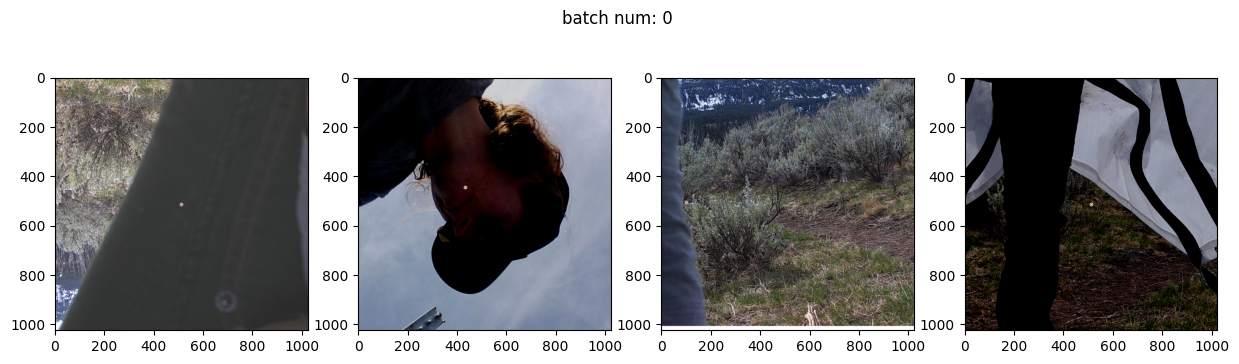

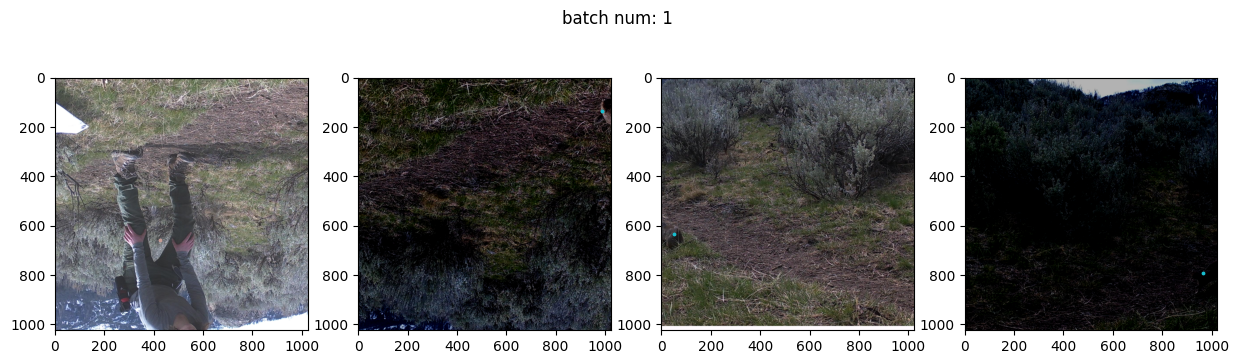

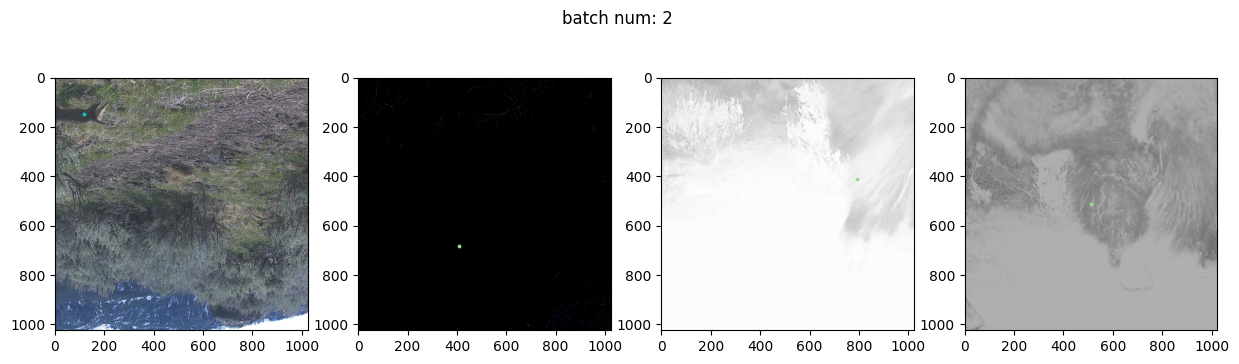

In [10]:
visualize = True
# First batch to visualize
first_batch_vis = 0
# Last batch to visualize
last_batch_vis = 3

import matplotlib.cm as cm                                                                                                                                                                                          
num_fg = num_classes - 1  # exclude background
class_colors = [cm.tab20(i / max(num_fg - 1, 1)) for i in range(num_fg)]   

if visualize:
    
    train_dataset = CocoDetection(image_folder,
                                  train_json_path,
                                  transform=train_data_transform)

    data_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=cfg['training']['batch_size'], shuffle=False, 
            num_workers=cfg['training']['num_workers'], collate_fn=collate_fn,
            worker_init_fn=worker_init_fn
    )
    
    for ind, data in enumerate(data_loader):
        if ind < first_batch_vis:
            continue
        if ind >= last_batch_vis:
            break
        
        im_batch, tar_batch = data
        fig, axs = plt.subplots(1, 4, figsize=(15, 4))
        fig.suptitle(f"batch num: {ind}")
        for batch_ind, (im, tar) in enumerate(zip(im_batch, tar_batch)):
            im = im.permute(1, 2, 0).numpy()
            axs[batch_ind].imshow(im)
            boxes = tar['boxes']
            labels = tar['labels']
            for box, label in zip(boxes, labels):
                label = label - 1 # Don't give background class a color
                color = class_colors[label % len(class_colors)]
                box = box.numpy()
                axs[batch_ind].scatter(np.mean([box[0], box[2]]), np.mean([box[1], box[3]]), s=3, c=color)

# Train model

In [11]:
train(cfg, model, optimizer, lr_scheduler, train_data_transform,
      val_data_transform)

loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


/cluster/medbow/project/wildimageproc/software/detection-projects/koger_detection/koger_detection/obj_det/engine.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [   0/4273]  eta: 3:39:13  lr: 0.000010  loss: 3.0648 (3.0648)  loss_classifier: 2.9602 (2.9602)  loss_box_reg: 0.0337 (0.0337)  loss_objectness: 0.0483 (0.0483)  loss_rpn_box_reg: 0.0226 (0.0226)  time: 3.0783  data: 1.0832  max mem: 10261
Epoch: [0]  [ 200/4273]  eta: 0:25:50  lr: 0.001009  loss: 0.2514 (0.6489)  loss_classifier: 0.0957 (0.4605)  loss_box_reg: 0.0850 (0.0873)  loss_objectness: 0.0236 (0.0648)  loss_rpn_box_reg: 0.0272 (0.0363)  time: 0.3677  data: 0.0063  max mem: 10431


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x151c6ea0c7c0>
Traceback (most recent call last):
  File "/cluster/medbow/project/wildimageproc/software/.wildimageproc-venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/cluster/medbow/project/wildimageproc/software/.wildimageproc-venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/cluster/medbow/home/omartin9/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cluster/medbow/home/omartin9/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

# Check model output on some validation images

In [ ]:
data_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=1, shuffle=False, 
        num_workers=4) #, collate_fn=collate_fn)

In [ ]:
_ = model.eval()

### Compare ground truth to predictions

In [ ]:
max_batch = 2
for ind, (images, tar) in enumerate(data_loader):
    if ind >= max_batch:
        break
    images = list(img.to(torch.device('cuda')) for img in images)
    # im = im[0]
    res = model(images)[0]
    boxes = res['boxes'].to('cpu').detach().numpy().astype(np.uint32)
    scores = res['scores'].to('cpu').detach().numpy()
    im = images[0].cpu().numpy().transpose(1, 2, 0).copy() # Copy makes circle work for unclear reasons
    im_preds = im.copy()
    for box, score in zip(boxes, scores):
        if score < .5:
            continue
        x = np.mean([box[0], box[2]])
        y = np.mean([box[1], box[3]])
        cv2.circle(im_preds, [int(x), int(y)], 3, (1.0, 0, 1.0), -1)
    for box in tar['boxes'][0]:
        box = box.numpy()
        x = np.mean([box[0], box[2]])
        y = np.mean([box[1], box[3]])
        cv2.circle(im_preds, [int(x), int(y)], 6, (1.0, 1.0, 1.0), 1)
        
    plt.figure(figsize=(10,10))
    plt.imshow(im_preds)